In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig

# Data preparation

In [2]:
df = pd.read_csv('paths_finished.tsv', sep='\t', names=["hashedIpAddress","timestamp","durationInSec","path","rating"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51318 entries, 0 to 51317
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hashedIpAddress  51315 non-null  str    
 1   timestamp        51318 non-null  int64  
 2   durationInSec    51318 non-null  int64  
 3   path             51318 non-null  str    
 4   rating           28501 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.0 MB


In [3]:
df.head()

,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0


In [4]:
paths = df['path'].tolist()

In [5]:
def create_edges_from_paths(paths: list[str]) -> list[tuple[str, str]]:

    edges = []

    for path in paths:
        pages = path.split(";")

        stack = []
        previous_page = None

        for page in pages:

            if page == "<":
                if stack:
                    previous_page = stack.pop()

            else:
                if previous_page is not None:
                    edges.append((previous_page, page))

                stack.append(previous_page)
                previous_page = page

    return edges

In [6]:
def create_graph_from_paths(paths: list[str]) -> ig.Graph:
    edges = create_edges_from_paths(paths)
    edges = pd.DataFrame(edges, columns=["source", "target"])
    edges.drop_duplicates(inplace=True)
    return ig.Graph.DataFrame(edges, use_vids=False, directed=True)

14th_century;15th_century;16th_century;Pacific_Ocean;Atlantic_Ocean;Accra;Africa;Atlantic_slave_trade;African_slave_trade
14th_century;Europe;Africa;Atlantic_slave_trade;African_slave_trade
14th_century;Niger;Nigeria;British_Empire;Slavery;Africa;Atlantic_slave_trade;African_slave_trade


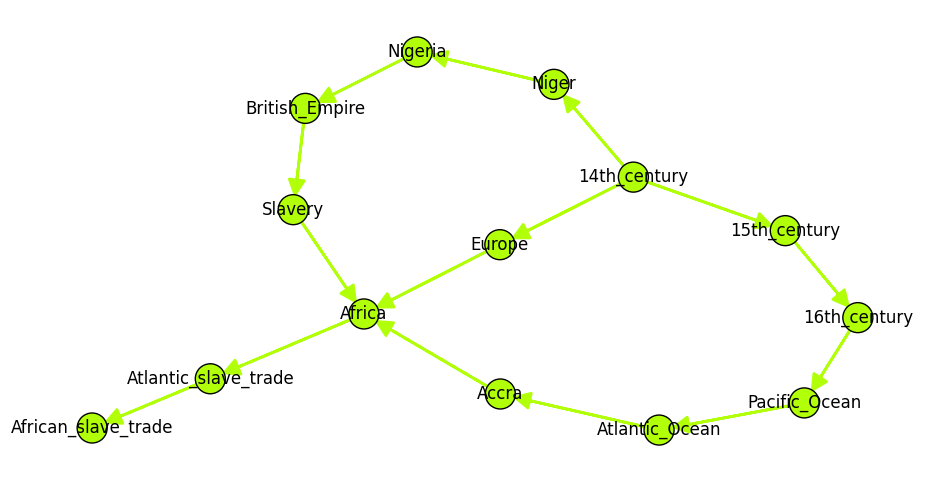

In [7]:
subset_paths = paths[0:3]
for path in subset_paths:
    print(path)
g = create_graph_from_paths(subset_paths)
fig, ax = plt.subplots(figsize=(12, 6))
ig.plot(g, target=ax,vertex_label=g.vs["name"], vertex_color="#B1FF08", edge_color="#B1FF08")

plt.show()

14th_century;Europe;<;England;<;Christianity;Anglicanism;United_States;Walt_Whitman;<;Poetry_of_the_United_States;<;<;<;French_Revolution;Age_of_Enlightenment;David_Hume;Philosophy;Fyodor_Dostoevsky;<;<;<;<;Constitutional_monarchy;Government;Anarchism;Henry_David_Thoreau
Aberdeen;Petroleum;Climate_change;Global_warming;Greenhouse_effect;Carbon_dioxide;Earth%27s_atmosphere;<;<;<;Kyoto_Protocol;<;Sea_level_rise;Effects_of_global_warming


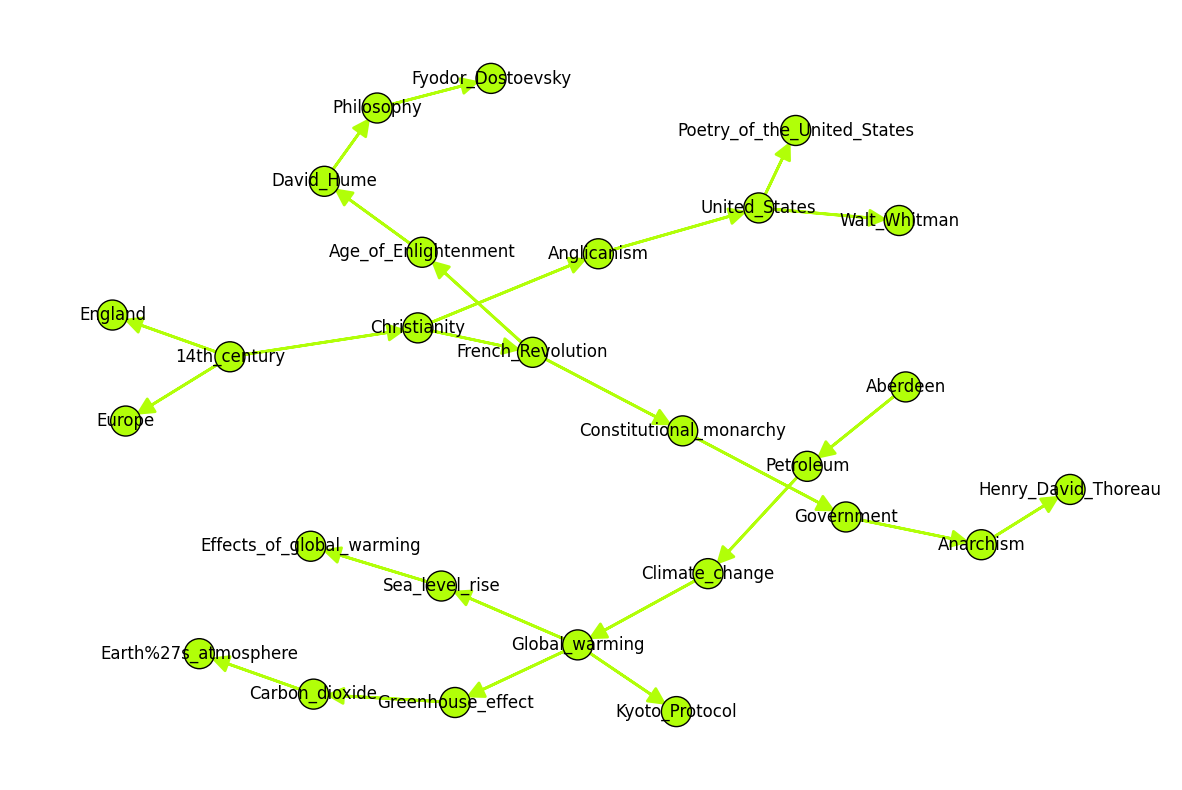

In [8]:
paths_with_back = [path for path in paths if "<;<;<" in path]
subset_paths = paths_with_back[0:2]
for path in subset_paths:
    print(path)
g = create_graph_from_paths(subset_paths)
fig, ax = plt.subplots(figsize=(15, 10))
ig.plot(g, target=ax,vertex_label=g.vs["name"], vertex_color="#B1FF08", edge_color="#B1FF08")
plt.show()

In [9]:
graph = create_graph_from_paths(paths)

# PageRank

In [10]:
def get_top_n_pagerank(graph: ig.Graph, n: int, personalized: list = None) -> pd.DataFrame:
    if personalized:
        reset_vertices = [graph.vs.find(name=target).index for target in personalized]
        pagerank = graph.personalized_pagerank(reset_vertices=reset_vertices)
    else:
        pagerank = graph.pagerank()
    df_pagerank = pd.DataFrame({
        "node": graph.vs["name"],
        "pagerank": pagerank
    })
    return df_pagerank.sort_values("pagerank", ascending=False).head(n).reset_index(drop=True)

In [11]:
get_top_n_pagerank(graph, 20)

,node,pagerank
0,United_States,0.016869
1,Europe,0.009784
2,United_Kingdom,0.009187
3,England,0.007301
4,World_War_II,0.006960
5,France,0.006916
6,Germany,0.005464
7,English_language,0.005241
8,Africa,0.004917
9,India,0.004394


In [12]:
target = "Periodic_table"
get_top_n_pagerank(graph, 20, personalized=[target])


,node,pagerank
0,Periodic_table,0.163464
1,Chemical_element,0.012663
2,United_States,0.010665
3,Russia,0.006845
4,Metal,0.005986
5,List_of_elements_by_name,0.005677
6,Europe,0.005402
7,Germany,0.005120
8,United_Kingdom,0.004752
9,Earth,0.004746


In [13]:
target = "Vegetable"
get_top_n_pagerank(graph, 20, personalized=[target])

,node,pagerank
0,Vegetable,0.152506
1,United_States,0.013794
2,Plant,0.009270
3,English_language,0.009253
4,Europe,0.008413
5,Human,0.008218
6,Agriculture,0.008053
7,Fruit,0.007903
8,Vitamin,0.007162
9,Vitamin_C,0.006947


In [14]:
g_rev = g.copy()
g_rev.reverse_edges()
get_top_n_pagerank(g_rev, 20)

,node,pagerank
0,14th_century,0.122842
1,Christianity,0.107593
2,French_Revolution,0.074600
3,Aberdeen,0.069949
4,Petroleum,0.068617
5,Climate_change,0.067050
6,Global_warming,0.065206
7,Anglicanism,0.038304
8,Age_of_Enlightenment,0.037044
9,Constitutional_monarchy,0.037044
